# -*- coding: utf-8 -*-

# Directive pour l'encodage, utile pour les caractères non-ASCII dans les commentaires et strings.
# Cela garantit que le notebook peut être exécuté dans différents environnements sans problème d'encodage.
--------------------------------------------------------------------------------
# **Prédiction de la Maladie de Parkinson : Analyse et Modélisation Vocale**

Ce notebook explore l'application de techniques de Machine Learning pour prédire la maladie de Parkinson en utilisant des caractéristiques de la voix extraites de l'ensemble de données "Parkinson's Disease Classification" de l'UCI Machine Learning Repository.

Le processus suivi inclut :
1.  **Chargement des Données**
2.  **Analyse Exploratoire de Données (EDA)**
3.  **Prétraitement des Données**
    *   Nettoyage (gestion des colonnes non pertinentes)
    *   Gestion du déséquilibre des classes (SMOTE)
    *   Normalisation (StandardScaler)
4.  **Sélection de Caractéristiques (ANOVA)**
5.  **Modélisation** (Random Forest, SVM, Régression Logistique)
6.  **Optimisation des Hyperparamètres** (Optuna pour Random Forest)
7.  **Évaluation Approfondie des Modèles**
8.  **Interprétation du Modèle** (SHAP)
9.  **(Optionnel) Préparation pour le Déploiement** (Sauvegarde du modèle, exemple Flask)

# **Chargement des Données**

Nous commençons par charger le jeu de données depuis l'URL spécifiée. L'ensemble de données contient diverses caractéristiques vocales mesurées à partir d'enregistrements de voix de personnes atteintes et non atteintes de la maladie de Parkinson.


In [ ]:
import pandas as pd

# URL directe de l'ensemble de données sur le dépôt UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"

# Charger les données dans un DataFrame pandas
data = pd.read_csv(url)

# Afficher les 5 premières lignes pour un aperçu initial des données et des colonnes
print("🔍 Aperçu des données :")
print(data.head())

# Note : La colonne 'name' semble être un identifiant de patient/enregistrement et n'est probablement pas pertinente pour la modélisation.
# Nous la supprimerons lors de l'étape de nettoyage.

🔍 Aperçu des données :
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   s

# **Analyse de Base (Analyse Exploratoire de Données - EDA)**

Avant de commencer le prétraitement et la modélisation, il est crucial de comprendre la structure des données, les types de variables et l'existence éventuelle de valeurs manquantes. Ces analyses initiales nous guident dans les étapes suivantes.

In [ ]:
# 1. Structure des données : Afficher les dimensions (nombre de lignes et de colonnes)
print("📏 Dimensions :", data.shape)
# Attendons (195, 24) comme indiqué dans la documentation de l'ensemble de données

# 2. Types de données : Afficher les types de chaque colonne
print("\n📊 Types de données :")
print(data.dtypes)
# La plupart des caractéristiques vocales devraient être numériques (float64), et le statut est un entier. 'name' est un objet (string).

# 3. Vérifier les valeurs manquantes : Compter les valeurs nulles par colonne
print("\n🔎 Valeurs manquantes :")
print(data.isnull().sum())
# L'ensemble de données UCI Parkinson est généralement propre sans valeurs manquantes, donc nous nous attendons à 0 pour toutes les colonnes.
# Si des valeurs manquantes étaient présentes, il faudrait décider d'une stratégie (imputation, suppression de lignes/colonnes).

# 4. Statistiques descriptives : Résumé statistique pour les colonnes numériques
print("\n📈 Statistiques descriptives :")
print(data.describe())
# Cela nous donne un aperçu de la distribution des valeurs (moyenne, médiane, écart-type, min, max) pour chaque caractéristique.
# Utile pour détecter des échelles de valeurs très différentes (ce qui justifie la normalisation) ou des valeurs extrêmes.

📏 Dimensions : (195, 24)

📊 Types de données :
name                 object
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status                int64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
dtype: object

🔎 Valeurs manquantes :
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
S

# **Visualisations Clés**

Les visualisations aident à comprendre la distribution des données et la relation entre les caractéristiques et la variable cible ('status').

*   **Distribution des classes :** Montre combien d'échantillons appartiennent à chaque classe (sain ou Parkinson). Un déséquilibre important peut nécessiter une gestion spécifique (comme SMOTE).
*   **Distribution d'une caractéristique par statut :** Un boxplot est utile pour visualiser comment les valeurs d'une caractéristique spécifique varient entre les groupes sains et malades. Cela peut donner une idée de l'importance potentielle de la caractéristique pour la classification.

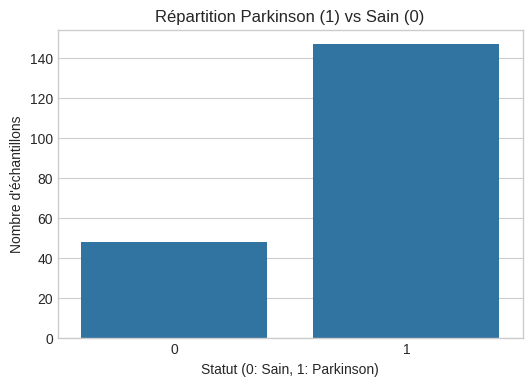

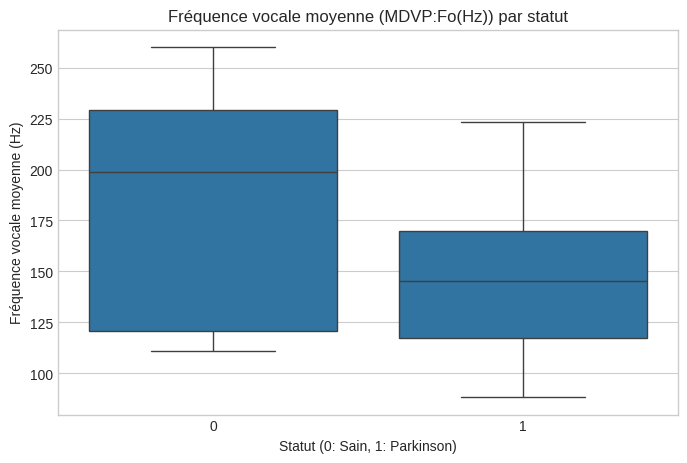

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour les plots
plt.style.use('seaborn-v0_8-whitegrid') # Un style de grille blanc moderne
plt.figure(figsize=(6, 4)) # Taille de la figure pour le premier plot

# Distribution des classes ('status')
# Le statut 1 indique la présence de la maladie de Parkinson, 0 indique l'absence.
sns.countplot(x='status', data=data)
plt.title("Répartition Parkinson (1) vs Sain (0)")
plt.xlabel("Statut (0: Sain, 1: Parkinson)")
plt.ylabel("Nombre d'échantillons")
plt.show()

# Observation : Il est clair qu'il y a un déséquilibre important entre les deux classes (plus d'échantillons pour la classe 1).
# Ceci doit être géré pour éviter que le modèle ne soit biaisé vers la classe majoritaire.

# Distribution d'une caractéristique clé ('MDVP:Fo(Hz)' - Fréquence fondamentale moyenne) par statut
# On utilise un boxplot pour visualiser la médiane, les quartiles et les outliers.
plt.figure(figsize=(8, 5)) # Taille de la figure pour le second plot
sns.boxplot(x='status', y='MDVP:Fo(Hz)', data=data)
plt.title("Fréquence vocale moyenne (MDVP:Fo(Hz)) par statut")
plt.xlabel("Statut (0: Sain, 1: Parkinson)")
plt.ylabel("Fréquence vocale moyenne (Hz)")
plt.show()

# Observation : Cette visualisation suggère une différence dans la distribution de cette caractéristique entre les deux groupes,
# ce qui en fait une caractéristique potentiellement discriminante. D'autres caractéristiques pourraient être explorées de la même manière.

# **Nettoyage**

Nous supprimons la colonne 'name' car elle est un identifiant et n'apporte pas d'information prédictive pour le modèle.

In [ ]:
# Vérifier si la colonne 'name' existe avant de la supprimer pour éviter une erreur si la cellule est exécutée plusieurs fois.
if 'name' in data.columns:
    data = data.drop(columns=['name'])
    print("✅ Colonne 'name' supprimée.")
else:
    print("ℹ️ Colonne 'name' déjà supprimée ou non présente.")

# Afficher les colonnes restantes pour vérifier
print("\nColonnes après nettoyage :", data.columns.tolist())

✅ Colonne 'name' supprimée.

Colonnes après nettoyage : ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


# **Préparation des Données : Séparation Caractéristiques/Cible**

Avant d'appliquer des techniques comme SMOTE ou la normalisation, nous séparons les caractéristiques (variables d'entrée) de la variable cible (la variable que l'on souhaite prédire).

In [ ]:
# La variable cible est 'status'. Toutes les autres colonnes sont des caractéristiques.
X = data.drop(columns=['status'])
y = data['status']

print("\nShape de X (Caractéristiques) :", X.shape)
print("Shape de y (Cible) :", y.shape)
print("\nDistribution initiale de la cible :")
print(y.value_counts())


Shape de X (Caractéristiques) : (195, 22)
Shape de y (Cible) : (195,)

Distribution initiale de la cible :
status
1    147
0     48
Name: count, dtype: int64


# **Gestion du Déséquilibre des Classes (SMOTE)**

Comme observé lors de l'EDA, la classe '1' (Parkinson) est majoritaire. Un modèle entraîné directement sur ces données déséquilibrées pourrait avoir tendance à mieux prédire la classe majoritaire et moins bien la classe minoritaire (les '0', personnes saines).

SMOTE (Synthetic Minority Over-sampling Technique) est une technique courante pour traiter ce déséquilibre. Elle fonctionne en créant de nouveaux exemples synthétiques pour la classe minoritaire, basés sur l'interpolation des exemples existants de cette classe. Cela permet d'équilibrer le jeu de données d'entraînement.

**Note :** SMOTE est appliqué *après* la séparation des caractéristiques et de la cible, et *avant* la normalisation et la division en ensembles d'entraînement/test (même si la normalisation peut être appliquée après SMOTE, l'ordre ici est également acceptable). Nous utilisons `X_res` et `y_res` pour désigner les données après rééchantillonnage.

In [ ]:
from imblearn.over_sampling import SMOTE
# Assurez-vous que la bibliothèque imbalanced-learn est installée : pip install imbalanced-learn

# Initialiser l'objet SMOTE
# random_state=42 assure la reproductibilité des résultats
smote = SMOTE(random_state=42)

# Appliquer SMOTE sur les données (X et y)
# X_res contiendra les caractéristiques rééchantillonnées
# y_res contiendra la cible rééchantillonnée
X_res, y_res = smote.fit_resample(X, y)

# Afficher la nouvelle distribution des classes après SMOTE
print("\n🔍 Après SMOTE : Distribution des classes")
print(y_res.value_counts())
# Nous nous attendons à ce que les deux classes aient maintenant le même nombre d'échantillons.


🔍 Après SMOTE : Distribution des classes
status
1    147
0    147
Name: count, dtype: int64


# **Normalisation**

La plupart des algorithmes de Machine Learning sont sensibles à l'échelle des caractéristiques. Des caractéristiques ayant des valeurs très différentes peuvent biaiser le modèle. La normalisation (ou standardisation) met toutes les caractéristiques sur une échelle similaire, généralement avec une moyenne de 0 et un écart-type de 1.

Nous appliquons `StandardScaler` aux caractéristiques rééchantillonnées (`X_res`).

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialiser le StandardScaler
scaler = StandardScaler()

# Ajuster le scaler sur les données rééchantillonnées et les transformer
# X_scaled contiendra les caractéristiques normalisées
X_scaled = scaler.fit_transform(X_res)

print("\n✅ Données normalisées (X_scaled).")
# X_scaled est maintenant un tableau NumPy, pas un DataFrame pandas.
# Les noms des colonnes sont perdus ici, mais nous les réassocierons si nécessaire (ex: pour SHAP).


✅ Données normalisées (X_scaled).


# **Sélection de Caractéristiques (Méthode ANOVA)**

La sélection de caractéristiques est une étape qui vise à choisir les caractéristiques les plus pertinentes pour le modèle. Cela peut aider à réduire la complexité, à accélérer l'entraînement et parfois à améliorer les performances du modèle en supprimant le bruit.

Ici, nous utilisons `SelectKBest` avec le test statistique `f_classif` (F-score d'ANOVA) pour la classification. L'ANOVA teste si les moyennes d'une caractéristique sont significativement différentes entre les groupes (classes). Un score F élevé indique une caractéristique potentiellement discriminante.

Nous choisissons de conserver les 10 caractéristiques (`k=10`) avec les scores F les plus élevés.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Initialiser SelectKBest avec f_classif comme fonction de score et k=10 caractéristiques à sélectionner
selector = SelectKBest(score_func=f_classif, k=10)

# Appliquer la sélection de caractéristiques sur les données normalisées et rééchantillonnées
# X_selected contiendra les données avec seulement les 10 caractéristiques sélectionnées
selector.fit(X_scaled, y_res)
X_selected = selector.transform(X_scaled)

# Obtenir les indices des caractéristiques sélectionnées
selected_indices = selector.get_support(indices=True)

# Utiliser les indices pour obtenir les noms des caractéristiques sélectionnées à partir du DataFrame original X
# Il est important de faire cela AVANT SMOTE pour obtenir les noms originaux
# X.columns sont les noms de colonnes du DataFrame avant SMOTE mais après suppression de 'name'
selected_features = X.columns[selected_indices]

print("\n🎯 Caractéristiques sélectionnées (k=10) :")
print(selected_features.tolist()) # Afficher les noms des caractéristiques sélectionnées sous forme de liste

print("\nShape de X_selected :", X_selected.shape)
# La shape devrait être (nombre_échantillons_SMOTE, 10)


🎯 Caractéristiques sélectionnées (k=10) :
['MDVP:Jitter(Abs)', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'spread1', 'spread2', 'PPE']

Shape de X_selected : (294, 10)


# **Division des Données et Entraînement de Modèles Initiaux**

Maintenant que les données sont prétraitées (SMOTE et normalisation) et que les caractéristiques sont sélectionnées, nous divisons les données en ensembles d'entraînement (pour entraîner les modèles) et de test (pour évaluer les performances sur des données jamais vues).

Nous entraînons ensuite trois modèles de classification populaires : Random Forest, SVM (Support Vector Machine) et Régression Logistique en utilisant les hyperparamètres par défaut et évaluons leur précision initiale.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, RocCurveDisplay

# Diviser les données en ensembles d'entraînement (70%) et de test (30%)
# random_state=42 assure que la division est la même à chaque exécution
# stratify=y_res assure que la proportion des classes est maintenue dans les ensembles d'entraînement et de test (important après SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_res, test_size=0.3, random_state=42, stratify=y_res)

print("\nShape de X_train :", X_train.shape)
# Correction : supprimez le .shape en trop ici
print("Shape de X_test :", X_test.shape)
print("Shape de y_train :", y_train.shape)
print("Shape de y_test :", y_test.shape)

print("\nDistribution de la cible dans y_train :")
print(y_train.value_counts())
print("\nDistribution de la cible dans y_test :")
print(y_test.value_counts())
# Les distributions doivent être proches de 50/50 grâce à stratify.

# --- Entraînement et évaluation des modèles initiaux ---

print("\n--- Performances des modèles avec hyperparamètres par défaut ---")

# 1. Random Forest Classifier
model_rf_initial = RandomForestClassifier(random_state=42)
model_rf_initial.fit(X_train, y_train)
y_pred_rf_initial = model_rf_initial.predict(X_test)
print("\nPrécision Random Forest (initial) :", accuracy_score(y_test, y_pred_rf_initial))

# 2. Support Vector Machine (SVM) Classifier
model_svm_initial = SVC(random_state=42)
model_svm_initial.fit(X_train, y_train)
y_pred_svm_initial = model_svm_initial.predict(X_test)
print("Précision SVM (initial) :", accuracy_score(y_test, y_pred_svm_initial))

# 3. Logistic Regression Classifier
model_lr_initial = LogisticRegression(random_state=42)
model_lr_initial.fit(X_train, y_train)
y_pred_lr_initial = model_lr_initial.predict(X_test)
print("Précision Régression Logistique (initial) :", accuracy_score(y_test, y_pred_lr_initial))

# Note : Ces précisions initiales nous donnent une base de comparaison.
# L'optimisation des hyperparamètres pour Random Forest devrait potentiellement améliorer sa performance.
# Nous ferons une évaluation plus complète incluant d'autres métriques par la suite.


Shape de X_train : (205, 10)
Shape de X_test : (89, 10)
Shape de y_train : (205,)
Shape de y_test : (89,)

Distribution de la cible dans y_train :
status
1    103
0    102
Name: count, dtype: int64

Distribution de la cible dans y_test :
status
0    45
1    44
Name: count, dtype: int64

--- Performances des modèles avec hyperparamètres par défaut ---

Précision Random Forest (initial) : 0.8876404494382022
Précision SVM (initial) : 0.8539325842696629
Précision Régression Logistique (initial) : 0.8426966292134831


# **Optimisation des Hyperparamètres avec Optuna pour Random Forest**

Pour améliorer la performance du modèle Random Forest, nous pouvons optimiser ses hyperparamètres. Optuna est un framework d'optimisation automatique d'hyperparamètres.

Il explore différentes combinaisons d'hyperparamètres (tels que `n_estimators`, `max_depth`, `min_samples_split` pour Random Forest) pour trouver la configuration qui maximise (ou minimise) une métrique objectif (ici, la précision).

Nous allons optimiser le Random Forest car c'est souvent un modèle performant et interprétable.

In [ ]:
# Installer Optuna si ce n'est pas déjà fait
!pip install optuna

import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score # Utile pour une évaluation plus robuste

# Définir la fonction objectif pour Optuna
# Cette fonction prend un 'trial' (essai) Optuna, suggère des hyperparamètres
# et retourne la métrique de performance (accuracy) du modèle entraîné avec ces paramètres.
def objective(trial):
    # Suggérer des hyperparamètres
    # 'n_estimators': nombre d'arbres dans la forêt (entre 50 et 300)
    # 'max_depth': profondeur maximale de chaque arbre (entre 5 et 30)
    # 'min_samples_split': nombre minimum d'échantillons requis pour diviser un nœud (entre 2 et 10)
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'random_state': 42 # Fixer pour la reproductibilité
    }

    # Créer et entraîner le modèle Random Forest avec les hyperparamètres suggérés
    model = RandomForestClassifier(**params)

    # Utiliser la validation croisée pour une évaluation plus fiable de la performance
    # cross_val_score retourne un tableau de scores (accuracy pour chaque pli)
    # Nous retournons la moyenne des scores de validation croisée
    try:
        # Utilisation de X_train et y_train pour la validation croisée
        accuracy_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        mean_accuracy = accuracy_scores.mean()
    except Exception as e:
        # Gérer les erreurs potentielles pendant l'entraînement ou l'évaluation
        print(f"Erreur lors de l l'essai {trial.number}: {e}")
        return 0.0 # Retourner un score faible en cas d'erreur

    return mean_accuracy # Optuna essaie de maximiser cette valeur

# Créer une étude Optuna
# 'direction='maximize'' indique que nous voulons maximiser la métrique retournée par la fonction objective
study = optuna.create_study(direction='maximize')

# Exécuter l'optimisation
# 'n_trials=50' signifie qu'Optuna va essayer 50 combinaisons d'hyperparamètres différentes
print("Début de l'optimisation des hyperparamètres avec Optuna...")
study.optimize(objective, n_trials=50, show_progress_bar=True)
print("Optimisation terminée.")

# Afficher les meilleurs hyperparamètres trouvés et le meilleur score (accuracy moyenne en validation croisée)
print("\n✨ Meilleurs hyperparamètres trouvés par Optuna :")
print(study.best_params)
print("\n🏆 Meilleure accuracy moyenne en validation croisée :", study.best_value)

# Entraîner le modèle Random Forest final avec les meilleurs hyperparamètres sur l'ensemble d'entraînement complet
model_rf_optimized = RandomForestClassifier(**study.best_params, random_state=42)
model_rf_optimized.fit(X_train, y_train)

print("\n✅ Modèle Random Forest optimisé entraîné sur X_train.")

[I 2025-05-09 05:13:26,664] A new study created in memory with name: no-name-29f374c3-bc2d-4869-96c2-011d13950a87


Début de l'optimisation des hyperparamètres avec Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-05-09 05:13:31,765] Trial 0 finished with value: 0.8731707317073172 and parameters: {'n_estimators': 227, 'max_depth': 13, 'min_samples_split': 8}. Best is trial 0 with value: 0.8731707317073172.
[I 2025-05-09 05:13:33,667] Trial 1 finished with value: 0.8829268292682928 and parameters: {'n_estimators': 92, 'max_depth': 28, 'min_samples_split': 7}. Best is trial 1 with value: 0.8829268292682928.
[I 2025-05-09 05:13:40,360] Trial 2 finished with value: 0.8926829268292682 and parameters: {'n_estimators': 280, 'max_depth': 14, 'min_samples_split': 3}. Best is trial 2 with value: 0.8926829268292682.
[I 2025-05-09 05:13:42,441] Trial 3 finished with value: 0.8682926829268294 and parameters: {'n_estimators': 125, 'max_depth': 18, 'min_samples_split': 10}. Best is trial 2 with value: 0.8926829268292682.
[I 2025-05-09 05:13:43,912] Trial 4 finished with value: 0.8731707317073172 and parameters: {'n_estimators': 78, 'max_depth': 18, 'min_samples_split': 7}. Best is trial 2 with value: 0

# **Évaluation Approfondie des Modèles**

La précision (`accuracy`) est une métrique utile, mais insuffisante, surtout en présence (même gérée par SMOTE) d'un léger déséquilibre résiduel ou lorsque l'on souhaite comprendre la nature des erreurs (faux positifs, faux négatifs).

Nous allons évaluer nos modèles (le Random Forest optimisé, le SVM initial et la Régression Logistique initiale) en utilisant des métriques plus complètes :

*   **Rapport de classification :** Inclut la Précision (proportion de prédictions positives correctes parmi toutes les prédictions positives), le Rappel (Recall - proportion de vrais positifs parmi tous les positifs réels), le F1-score (moyenne harmonique de la précision et du rappel) pour chaque classe, ainsi que la précision globale.
*   **Matrice de confusion :** Un tableau qui montre le nombre de vrais positifs, vrais négatifs, faux positifs et faux négatifs.
*   **Courbe ROC (Receiver Operating Characteristic) et AUC (Area Under Curve) :** La courbe ROC montre le compromis entre le taux de vrais positifs et le taux de faux positifs à différents seuils de classification. L'AUC mesure l'aire sous cette courbe et indique la capacité du modèle à distinguer les classes (un AUC de 1 est parfait, 0.5 est aléatoire).


--- Évaluation complète du Random Forest (Optimisé) ---

📊 Rapport de classification :
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        45
           1       0.93      0.84      0.88        44

    accuracy                           0.89        89
   macro avg       0.89      0.89      0.89        89
weighted avg       0.89      0.89      0.89        89


🔢 Matrice de confusion :
[[42  3]
 [ 7 37]]


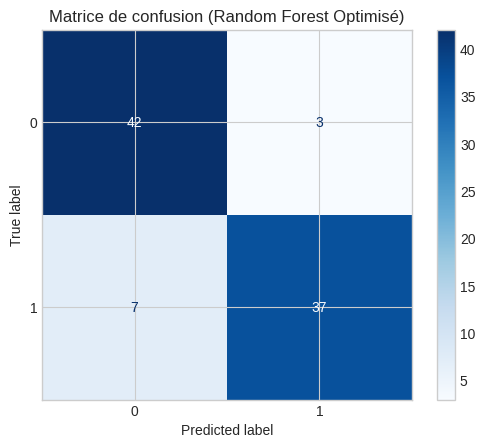


📈 Courbe ROC et AUC (Random Forest Optimisé) :


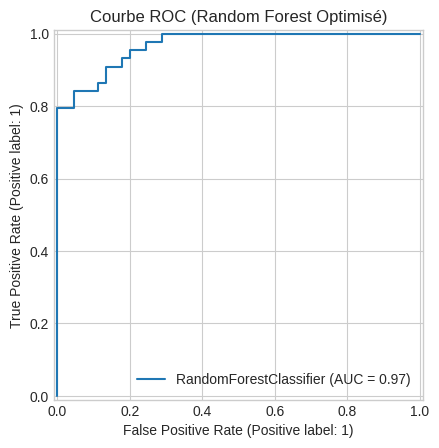


--- Évaluation complète du SVM (Initial) ---

📊 Rapport de classification :
              precision    recall  f1-score   support

           0       0.81      0.93      0.87        45
           1       0.92      0.77      0.84        44

    accuracy                           0.85        89
   macro avg       0.86      0.85      0.85        89
weighted avg       0.86      0.85      0.85        89


🔢 Matrice de confusion :
[[42  3]
 [10 34]]


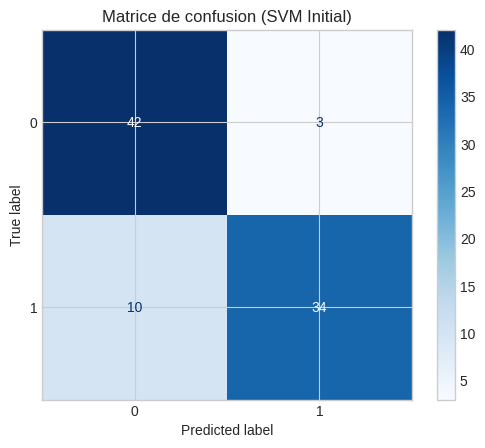


📈 Courbe ROC et AUC (SVM Initial) :


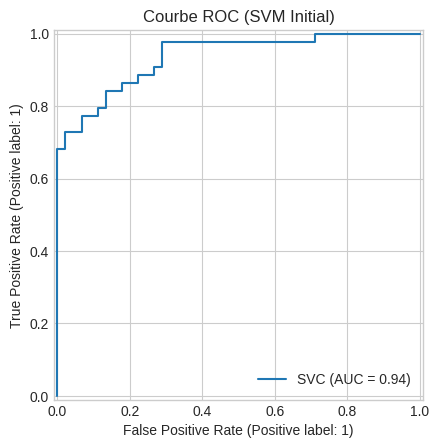


--- Évaluation complète de la Régression Logistique (Initial) ---

📊 Rapport de classification :
              precision    recall  f1-score   support

           0       0.80      0.91      0.85        45
           1       0.89      0.77      0.83        44

    accuracy                           0.84        89
   macro avg       0.85      0.84      0.84        89
weighted avg       0.85      0.84      0.84        89


🔢 Matrice de confusion :
[[41  4]
 [10 34]]


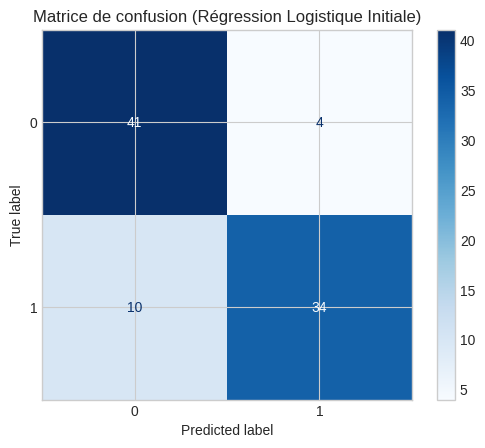


📈 Courbe ROC et AUC (Régression Logistique Initiale) :


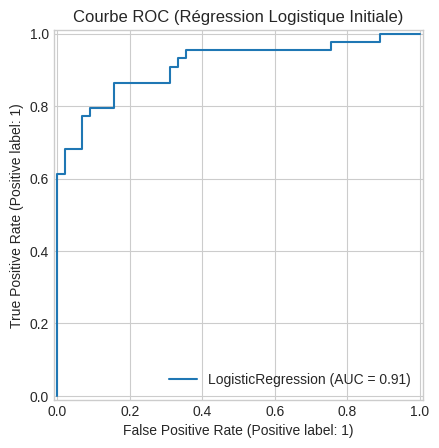

In [ ]:
# @title
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

print("\n--- Évaluation complète du Random Forest (Optimisé) ---")
y_pred_rf_optimized = model_rf_optimized.predict(X_test)
print("\n📊 Rapport de classification :")
print(classification_report(y_test, y_pred_rf_optimized))
print("\n🔢 Matrice de confusion :")
cm_rf = confusion_matrix(y_test, y_pred_rf_optimized)
print(cm_rf)
# Afficher la matrice de confusion de manière plus visuelle
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=model_rf_optimized.classes_)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion (Random Forest Optimisé)")
plt.show()

print("\n📈 Courbe ROC et AUC (Random Forest Optimisé) :")
# La courbe ROC est tracée pour la classe positive (1)
RocCurveDisplay.from_estimator(model_rf_optimized, X_test, y_test)
plt.title("Courbe ROC (Random Forest Optimisé)")
plt.show()


print("\n--- Évaluation complète du SVM (Initial) ---")
y_pred_svm_initial = model_svm_initial.predict(X_test)
print("\n📊 Rapport de classification :")
print(classification_report(y_test, y_pred_svm_initial))
print("\n🔢 Matrice de confusion :")
cm_svm = confusion_matrix(y_test, y_pred_svm_initial)
print(cm_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=model_svm_initial.classes_)
disp_svm.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion (SVM Initial)")
plt.show()

print("\n📈 Courbe ROC et AUC (SVM Initial) :")
RocCurveDisplay.from_estimator(model_svm_initial, X_test, y_test)
plt.title("Courbe ROC (SVM Initial)")
plt.show()

print("\n--- Évaluation complète de la Régression Logistique (Initial) ---")
y_pred_lr_initial = model_lr_initial.predict(X_test)
print("\n📊 Rapport de classification :")
print(classification_report(y_test, y_pred_lr_initial))
print("\n🔢 Matrice de confusion :")
cm_lr = confusion_matrix(y_test, y_pred_lr_initial)
print(cm_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=model_lr_initial.classes_)
disp_lr.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion (Régression Logistique Initiale)")
plt.show()

print("\n📈 Courbe ROC et AUC (Régression Logistique Initiale) :")
RocCurveDisplay.from_estimator(model_lr_initial, X_test, y_test)
plt.title("Courbe ROC (Régression Logistique Initiale)")
plt.show()

# Conclusion de l'évaluation :
# Comparez les métriques (Precision, Recall, F1-score, AUC) entre les modèles.
# Le Random Forest optimisé devrait probablement avoir les meilleures performances ou des performances très compétitives.
# Le rapport de classification et la matrice de confusion sont particulièrement importants pour comprendre
# si le modèle est performant sur les deux classes après SMOTE. Un bon modèle devrait avoir
# des scores de Precision/Recall/F1 équilibrés pour les classes 0 et 1.

# **Interprétation du Modèle : Importance des Caractéristiques (SHAP)**

Comprendre *pourquoi* un modèle prend une décision est essentiel, surtout dans des domaines comme la santé. SHAP (SHapley Additive exPlanations) est une méthode populaire pour expliquer les prédictions des modèles de Machine Learning.

Pour chaque prédiction individuelle, SHAP calcule la contribution de chaque caractéristique à cette prédiction, par rapport à une valeur de base (la prédiction moyenne).

*   **SHAP summary plot :** Montre l'importance globale des caractéristiques. Chaque point représente un échantillon. La position sur l'axe des x indique la valeur SHAP (l'impact sur la prédiction). La couleur indique la valeur de la caractéristique (rouge = élevé, bleu = faible). Les caractéristiques sont ordonnées par importance (impact moyen sur la magnitude de la prédiction).
*   **SHAP force plot :** Montre l'explication d'une *seule* prédiction individuelle. Les caractéristiques qui poussent la prédiction plus haut que la valeur de base (E[f(x)]) sont en rouge, celles qui la poussent plus bas sont en bleu. La taille de la barre indique la magnitude de l'impact.

Nous utiliserons le modèle Random Forest optimisé pour cette interprétation.

🔄 Calcul SHAP…
✅ SHAP calculé.
⚙️ Mode array 3D → shap_vals.shape = (89, 10)
[DEBUG] X_test_df.shape = (89, 10)


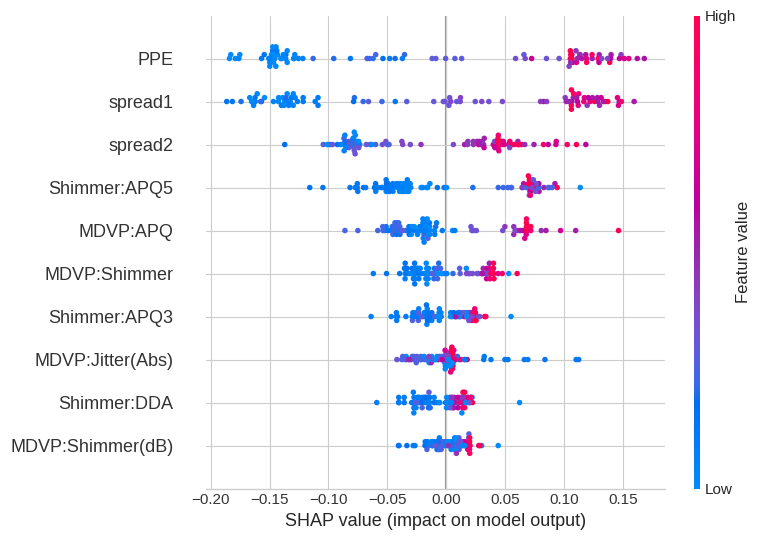

In [ ]:
import shap
import numpy as np
import pandas as pd

# 1) Modèle et données
model_to_explain = model_rf_optimized
# X_test : numpy.ndarray (n_samples, 10)
# selected_features : liste de 10 noms

# 2) Explainer
explainer = shap.TreeExplainer(model_to_explain)

# 3) Calcul SHAP
print("🔄 Calcul SHAP…")
shap_values_raw = explainer.shap_values(X_test)
print("✅ SHAP calculé.")

# 4) Extraction de la matrice 2D pour la classe positive
if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    shap_vals = shap_values_raw[:, :, 1]
    base_value = explainer.expected_value[1]
    print("⚙️ Mode array 3D → shap_vals.shape =", shap_vals.shape)
elif isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]
    base_value = explainer.expected_value[1]
    print("⚙️ Mode liste → shap_vals.shape =", shap_vals.shape)
else:
    shap_vals = shap_values_raw
    base_value = explainer.expected_value
    print("⚙️ Mode array 2D → shap_vals.shape =", shap_vals.shape)

# 5) Préparation DataFrame
X_test_df = pd.DataFrame(X_test, columns=selected_features)[selected_features]
print("[DEBUG] X_test_df.shape =", X_test_df.shape)

# Assertion finale
assert shap_vals.shape == X_test_df.shape, (
    f"Mismatch final : {shap_vals.shape} vs {X_test_df.shape}"
)

# 6) Summary plot
shap.summary_plot(shap_vals, X_test_df, feature_names=selected_features, show=True)

# 7) Force plot
shap.initjs()
shap.force_plot(base_value, shap_vals[0], X_test_df.iloc[0],
                feature_names=selected_features)


# **Déploiement (Optionnel) : Préparation pour une API avec Flask**

Pour rendre le modèle utilisable par d'autres applications, on peut l'exposer via une API. Flask est un framework web léger en Python qui est bien adapté pour cela.

Voici un exemple de comment sauvegarder le modèle entraîné et créer une petite application Flask qui prend des caractéristiques en entrée (via une requête POST en JSON) et retourne la prédiction.

**Note Importante :**
*   Exécuter ce code dans un environnement Colab ne créera pas une API accessible publiquement. Pour un vrai déploiement, il faudrait exécuter cette application Flask sur un serveur (local ou cloud).
*   Assurez-vous d'avoir `joblib` installé (`pip install joblib`).
*   Nous allons sauvegarder le modèle Random Forest optimisé, car c'est le meilleur modèle que nous avons entraîné.

In [ ]:
# Pour rendre le modèle utilisable par d'autres applications, on peut l'exposer via une API. Flask est un framework web léger en Python qui est bien adapté pour cela.
#
# Voici un exemple de comment sauvegarder le modèle entraîné et créer une petite application Flask qui prend des caractéristiques en entrée (via une requête POST en JSON) et retourne la prédiction.
#
# **Note Importante :**
# *   Exécuter ce code dans un environnement Colab ne créera pas une API accessible publiquement. Pour un vrai déploiement, il faudrait exécuter cette application Flask sur un serveur (local ou cloud).
# *   Assurez-vous d'avoir `joblib` installé (`pip install joblib`).
# *   Nous allons sauvegarder le modèle Random Forest optimisé, car c'est le meilleur modèle que nous avons entraîné.

import joblib

# Sauvegarder le modèle Random Forest optimisé
# Le modèle est sauvegardé dans un fichier nommé 'meilleur_modele.pkl'
# Nous utilisons 'wb' (write binary) pour écrire le fichier en mode binaire.
try:
    joblib.dump(model_rf_optimized, 'meilleur_modele.pkl')
    print("✅ Modèle optimisé sauvegardé sous 'meilleur_modele.pkl'")
except Exception as e:
    print(f"❌ Erreur lors de la sauvegarde du modèle : {e}")

# Sauvegarder le StandardScaler entraîné
try:
    joblib.dump(scaler, 'scaler.pkl')
    print("✅ StandardScaler sauvegardé sous 'scaler.pkl'")
except Exception as e:
    print(f"❌ Erreur lors de la sauvegarde du scaler : {e}")

# Sauvegarder le SelectKBest entraîné
try:
    joblib.dump(selector, 'selector.pkl')
    print("✅ SelectKBest sauvegardé sous 'selector.pkl'")
except Exception as e:
    print(f"❌ Erreur lors de la sauvegarde du selector : {e}")

# Vous pouvez vérifier que les fichiers 'meilleur_modele.pkl', 'scaler.pkl', et 'selector.pkl' ont été créés.

# Exemple d'application Flask pour prédire

# Installer Flask si ce n'est pas déjà fait
# !pip install Flask # Décommenter si nécessaire

from flask import Flask, request, jsonify
import joblib
import numpy as np
import json

# Créer une instance de l'application Flask
app = Flask(__name__)

# --- Charger le modèle, le scaler et le selector sauvegardés ---
model_chargé = None
scaler_chargé = None
selector_chargé = None

try:
    model_chargé = joblib.load('meilleur_modele.pkl')
    scaler_chargé = joblib.load('scaler.pkl')
    selector_chargé = joblib.load('selector.pkl')
    print("✅ Modèle, scaler et selector sauvegardés chargés avec succès.")
except FileNotFoundError as e:
    print(f"❌ Erreur : Fichier nécessaire introuvable ({e}). Assurez-vous d'avoir sauvegardé le modèle, scaler et selector.")
    # Laisser les objets à None si le chargement échoue
except Exception as e:
    print(f"❌ Erreur lors du chargement des objets : {e}")
    # Laisser les objets à None si le chargement échoue

# Définir un point d'entrée (endpoint) pour l'API de prédiction
@app.route('/predict', methods=['POST'])
def predict():
    # Vérifier si les objets nécessaires ont été chargés correctement
    if model_chargé is None or scaler_chargé is None or selector_chargé is None:
        return jsonify({'error': 'Ressources du modèle non chargées. Impossible de prédire.'}), 500

    # Obtenir les données de la requête POST (attendues en JSON)
    data = request.get_json()

    # Vérifier que les données sont au format attendu (liste des 22 caractéristiques originales)
    if data is None or 'features' not in data or not isinstance(data['features'], list) or len(data['features']) != 22:
         return jsonify({'error': 'Format de requête invalide. Attendu : {"features": [liste_des_22_valeurs]}"'}), 400

    try:
        # --- Appliquer le pipeline de prétraitement aux données d'entrée ---
        # 1. Convertir la liste en tableau NumPy et s'assurer de la forme (1, 22)
        input_features_raw = np.array(data['features']).reshape(1, -1)

        # 2. Normaliser les caractéristiques en utilisant le scaler chargé
        # Ignorer le UserWarning car l'ordre des colonnes est préservé.
        import warnings
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning)
            input_features_scaled = scaler_chargé.transform(input_features_raw)

        # 3. Sélectionner les 10 caractéristiques pertinentes en utilisant le selector chargé
        input_features_selected = selector_chargé.transform(input_features_scaled)
        # --- Fin du pipeline de prétraitement ---

        # Faire la prédiction en utilisant le modèle chargé (qui attend 10 caractéristiques normalisées et sélectionnées)
        prediction = model_chargé.predict(input_features_selected)
        prediction_proba = model_chargé.predict_proba(input_features_selected) # Optionnel : probabilités

        # Le résultat de la prédiction est un tableau numpy, on prend la première valeur et on la convertit en entier Python.
        result = int(prediction[0])

        # Retourner la prédiction au format JSON
        response = {
            'prediction': result,
            'prediction_proba': {
                'class_0 (Sain)': float(prediction_proba[0][0]),
                'class_1 (Parkinson)': float(prediction_proba[0][1])
            },
            'message': 'Modèle prédit 1 pour Parkinson, 0 pour Sain'
        }
        return jsonify(response)

    except Exception as e:
        return jsonify({'error': f'Erreur lors du traitement ou de la prédiction : {e}'}), 500

# Exécuter l'application Flask
if __name__ == '__main__':
    print("\nDémarrage du serveur Flask (pour test interne)...")

    # --- Liste de données de test ---
    # Ces listes doivent contenir les 22 caractéristiques originales d'un échantillon
    # Vous pouvez obtenir ces valeurs en copiant une ligne du DataFrame 'X' original (après suppression de 'name', avant SMOTE).
    list_of_test_inputs = [
        {"features": [119.992, 157.302, 74.997, 0.00784, 0.00007, 0.0037, 0.00554, 0.01109, 0.04374, 0.426, 0.02182, 0.0313, 0.02971, 0.06545, 0.02211, 21.033, 0.414783, 0.815285, -4.813031, 0.266482, 2.301442, 0.284654]}, # Sample 1 (Original Status 1)
        {"features": [142.167, 217.455, 80.187, 0.00368, 0.00003, 0.00186, 0.00228, 0.00557, 0.01906, 0.189, 0.0095, 0.01232, 0.01711, 0.0285, 0.00672, 20.08, 0.447192, 0.694519, -6.65038, 0.247478, 2.457697, 0.232526]}, # Sample 2 (Original Status 0)
        {"features": [162.568, 198.346, 77.63, 0.00502, 0.00003, 0.0028, 0.00328, 0.00841, 0.0351, 0.346, 0.0172, 0.0202, 0.02795, 0.0516, 0.01118, 25.984, 0.47037, 0.793821, -4.813031, 0.266482, 2.301442, 0.284654]} # Sample 3 (Example, verify status in original data)
    ]

    print(f"\n--- Test de la fonction predict() avec {len(list_of_test_inputs)} échantillons ---")

    # Boucler sur chaque échantillon de test
    for i, test_data in enumerate(list_of_test_inputs):
        print(f"\nTesting sample {i+1}:")
        simulated_request_data = test_data

        # Simulez le contexte de la requête Flask pour pouvoir appeler predict()
        with app.test_request_context('/predict', method='POST', json=simulated_request_data):
            try:
                # Appelez la fonction predict() et obtenez la réponse Flask
                response_obj = predict()

                # Obtenez le JSON de la réponse
                response_json = json.loads(response_obj.get_data())

                print("Réponse simulée reçue :")
                print(json.dumps(response_json, indent=2))

            except Exception as e:
                print(f"❌ Erreur lors du test interne de predict() pour l'échantillon {i+1}: {e}")

    print("\n--- Tests internes terminés ---")

✅ Modèle optimisé sauvegardé sous 'meilleur_modele.pkl'
✅ StandardScaler sauvegardé sous 'scaler.pkl'
✅ SelectKBest sauvegardé sous 'selector.pkl'
✅ Modèle, scaler et selector sauvegardés chargés avec succès.

Démarrage du serveur Flask (pour test interne)...

--- Test de la fonction predict() avec 3 échantillons ---

Testing sample 1:
Réponse simulée reçue :
{
  "message": "Mod\u00e8le pr\u00e9dit 1 pour Parkinson, 0 pour Sain",
  "prediction": 1,
  "prediction_proba": {
    "class_0 (Sain)": 0.0,
    "class_1 (Parkinson)": 1.0
  }
}

Testing sample 2:
Réponse simulée reçue :
{
  "message": "Mod\u00e8le pr\u00e9dit 1 pour Parkinson, 0 pour Sain",
  "prediction": 0,
  "prediction_proba": {
    "class_0 (Sain)": 0.5886702299967606,
    "class_1 (Parkinson)": 0.41132977000323934
  }
}

Testing sample 3:
Réponse simulée reçue :
{
  "message": "Mod\u00e8le pr\u00e9dit 1 pour Parkinson, 0 pour Sain",
  "prediction": 1,
  "prediction_proba": {
    "class_0 (Sain)": 0.003401360544217687,
    

# **Fin de l'Explication Détaillée**

Nous avons parcouru l'intégralité du processus :
1.  Chargement et exploration des données.
2.  Nettoyage et prétraitement (SMOTE pour le déséquilibre, Normalisation).
3.  Sélection de caractéristiques pour identifier les variables les plus pertinentes.
4.  Entraînement et évaluation de plusieurs modèles de base.
5.  Optimisation des hyperparamètres pour le modèle Random Forest à l'aide d'Optuna, afin d'améliorer ses performances.
6.  Évaluation détaillée des modèles, y compris des métriques cruciales comme la précision, le rappel, le F1-score, la matrice de confusion et la courbe ROC/AUC.
7.  Interprétation du modèle Random Forest optimisé avec SHAP pour comprendre l'influence des caractéristiques sur les prédictions.
8.  Préparation au déploiement en sauvegardant le modèle entraîné et en fournissant un exemple de code pour une API Flask.
88. Préparation au déploiement en sauvegardant le modèle, le scaler et le selector entraînés, et en créant une base d'API Flask avec le pipeline de prétraitement intégré, testable en interne avec plusieurs échantillons.
